In [2]:
import pysersic
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from photutils.datasets import make_noise_image
from photutils.centroids import centroid_quadratic
from photutils.profiles import RadialProfile
from astropy.io import fits

In [4]:
from pysersic import check_input_data, FitSingle
from pysersic.priors import autoprior
from pysersic.loss import student_t_loss
from pysersic.results import plot_image, plot_residual
from jax.random import PRNGKey # Need to use a seed to start jax's random number generation

In [5]:
from astropy import units as u
from astropy import constants as c

import astropy.cosmology as cosmology
H0=70 #km/s/Mpc
WM=0.3
cosmo = cosmology.FlatLambdaCDM(H0=H0, Om0=WM)

## Fitting Sersic profile

In [6]:
image = fits.open("***")[0].data ###science image
sigma = fits.open("***")[0].data ###sigma image (i.e., uncertainty of the science image)
mask = fits.open("***")[0].data ###mask image (i.e., the region which should be removed in the fitting)
psf = fits.open("***")[0].data ###Point spread function

FileNotFoundError: [Errno 2] No such file or directory: '***'

In [ ]:
###Plot the science image, sigma image, and point spread function
fig, ax = plot_image(image,mask,sigma,psf)

In [ ]:
###Checking the data set
check_input_data(data=image,rms=sigma,psf=psf,mask=mask)

In [ ]:
###Determining prior automatically
prior  = autoprior(image = image, profile_type = 'sersic', mask=mask, sky_type = 'none')

In [ ]:
###Setting the fitting procedure
fitter = FitSingle(data=image,rms=sigma,mask=mask,psf=psf,prior=prior,loss_func=student_t_loss)

###Finding MAP (Maximum A Posteriori)
map_params = fitter.find_MAP(rkey = PRNGKey(1000)) ###MAP=Maximum A Posteriori

In [ ]:
###Plotting the fitting result at MAP
fig, ax = plot_residual(image,map_params['model'],mask=mask,vmin=-1,vmax=1)

In [ ]:
###Estimate posterior distribution
res = fitter.estimate_posterior(rkey = PRNGKey(1001), method='laplace')

In [ ]:
###Showing the 16, 50 84 percentille of the distributions of the parameter
fitter.svi_results.retrieve_param_quantiles(return_dataframe=False) ###16, 50 84 percentille

In [ ]:
re = fitter.svi_results.retrieve_param_quantiles()["r_eff"][1] ###taking the median as the best-fit value, in the unit of pixel
flux = fitter.svi_results.retrieve_param_quantiles()["flux"][1] ###taking the median as the best-fit value, in the unit of 10 nJy

### Cell 1 — imports + version check

In [7]:
import sys, platform
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

print("Python:", sys.version)
print("Platform:", platform.platform())

# Pysersic
try:
    import pysersic
    print("pysersic:", pysersic.__version__ if hasattr(pysersic, "__version__") else "imported (no __version__)")
except Exception as e:
    print("ERROR importing pysersic:", e)

Python: 3.11.14 | packaged by conda-forge | (main, Jan 27 2026, 00:01:01) [Clang 19.1.7 ]
Platform: macOS-26.2-arm64-arm-64bit
pysersic: imported (no __version__)


### Step 2 — Plot the Sérsic profile for 4 (Re, n) pairs

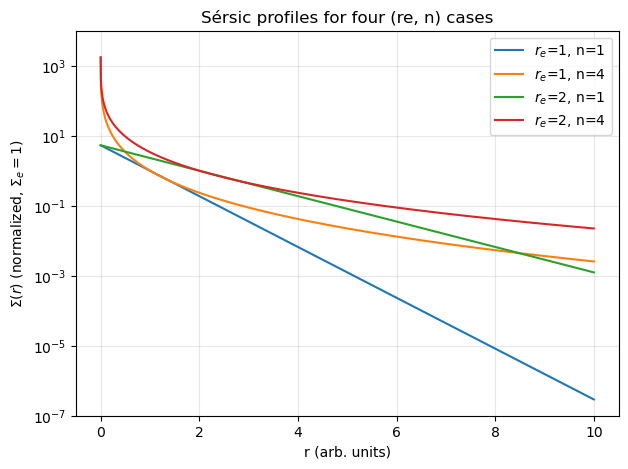

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def kappa_capaccioli(n):
    # Capaccioli et al. 1989 approximation: valid for 0.5 < n < 10
    return 1.9992*n - 0.3271

def sersic_sigma(r, re, n, sigma_e=1.0):
    k = kappa_capaccioli(n)
    return sigma_e * np.exp(-k * ((r/re)**(1/n) - 1.0))

# radius grid (arbitrary units). Choose wide enough to show differences.
r = np.linspace(0.0, 10.0, 2000)
r[0] = 1e-6  # avoid r=0 exactly (safe for fractional powers)

cases = [(1, 1), (1, 4), (2, 1), (2, 4)]

plt.figure(figsize=(7,5))
for re, n in cases:
    sigma = sersic_sigma(r, re=re, n=n, sigma_e=1.0)
    plt.plot(r, sigma, label=f"$r_e$={re}, n={n}")

plt.yscale("log")  # helps to see outer wings clearly
plt.xlabel("r (arb. units)")
plt.ylabel(r"$\Sigma(r)$ (normalized, $\Sigma_e=1$)")
plt.title("Sérsic profiles for four (re, n) cases")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.ylim(1e-7, 1e4)
plt.show()

### Step 3.1 — Plot science, sigma, mask, and PSF (Output 2)

Loaded:
  sci  : ./Sample1/Sample1-2_f277w-clear_sci.fits (125, 125)
  sigma: ./Sample1/Sample1-2_f277w-clear_sigma.fits (125, 125)
  mask : ./Sample1/Sample1-2_f277w-clear_mask.fits (125, 125)
  psf  : ./psf-f277w-clear.fits (121, 121) sum= 1.0


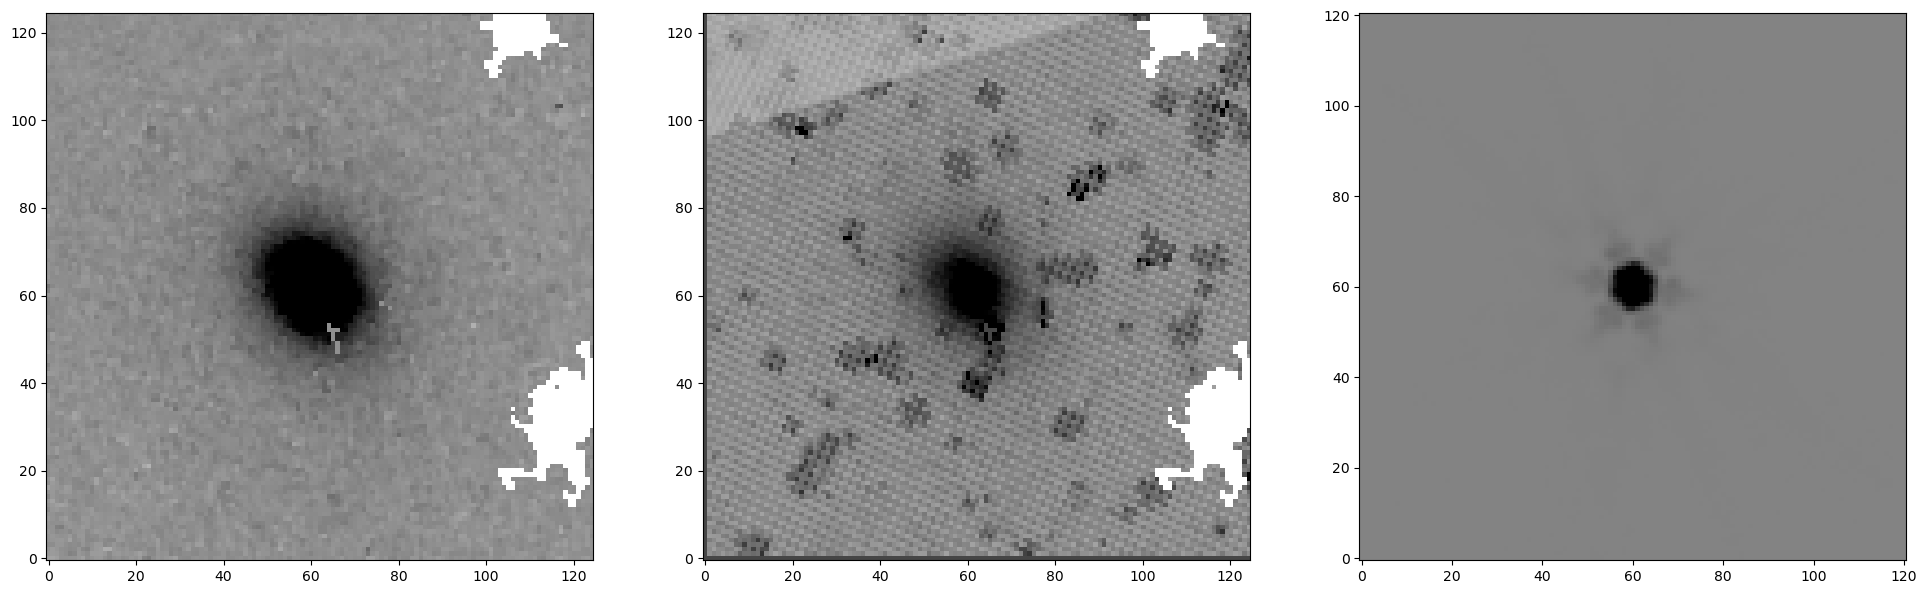

In [15]:
from astropy.io import fits
import numpy as np

# --- Choose which galaxy to plot ---
sample = 1   # 1 or 2
gal_id = 2   # 1, 2, or 3

# --- Paths (edit base_dir if needed) ---
base_dir = "."  # folder where Sample1/, Sample2/, psf-f277w-clear.fits live

sci_path   = f"{base_dir}/Sample{sample}/Sample{sample}-{gal_id}_f277w-clear_sci.fits"
sigma_path = f"{base_dir}/Sample{sample}/Sample{sample}-{gal_id}_f277w-clear_sigma.fits"
mask_path  = f"{base_dir}/Sample{sample}/Sample{sample}-{gal_id}_f277w-clear_mask.fits"
psf_path   = f"{base_dir}/psf-f277w-clear.fits"

# --- Load data ---
image = fits.open(sci_path)[0].data.astype(float)     # science image
sigma = fits.open(sigma_path)[0].data.astype(float)   # uncertainty image
mask  = fits.open(mask_path)[0].data.astype(float)    # mask image (1=masked or 0=masked depending on file)
psf   = fits.open(psf_path)[0].data.astype(float)     # PSF

# --- Optional but recommended: clean + normalize PSF for convolution ---
psf = np.nan_to_num(psf, nan=0.0)
psf_sum = psf.sum()
if psf_sum > 0:
    psf /= psf_sum

print("Loaded:")
print("  sci  :", sci_path,   image.shape)
print("  sigma:", sigma_path, sigma.shape)
print("  mask :", mask_path,  mask.shape)
print("  psf  :", psf_path,   psf.shape, "sum=", psf.sum())

# --- Plot using PySersic helper (Output 2) ---
fig, ax = plot_image(image, mask, sigma, psf)

### Step 3.2 — Determine priors with autoprior (one cell)

In [24]:
import numpy as np
from pysersic import FitSingle
from pysersic.priors import autoprior

# --- 0) Build boolean mask (True = masked pixels) ---
mask_bool = (mask > 0)
print(f"Mask unique values: {np.unique(mask)}")
print(f"Masked fraction: {mask_bool.mean():.3f}")

# --- 1) Auto-generate priors for a Sérsic source ---
# In your version: autoprior(image, mask=..., profile_type="sersic")
priors = autoprior(image, mask=mask_bool, profile_type="sersic")
print("✅ priors created:", type(priors))
print("Parameter names:", priors.param_names)

# --- 2) Initialize the fitter (your version uses data/rms/prior) ---
fitter = FitSingle(
    data=image,
    rms=sigma,      # sigma image provided by the exercise = per-pixel RMS
    psf=psf,        # normalized PSF is recommended (sum=1)
    prior=priors,
    mask=mask_bool
)
print("✅ fitter initialised:", type(fitter))

# --- 3) Confirm methods available for Step 3.3 ---
print("Available fitting methods:", [m for m in dir(fitter) if m in ["find_MAP", "estimate_posterior", "_train_SVI"]])

Mask unique values: [0. 1.]
Masked fraction: 0.032
✅ priors created: <class 'pysersic.priors.PySersicSourcePrior'>
Parameter names: ['flux', 'xc', 'yc', 'r_eff', 'ellip', 'theta', 'n']
✅ fitter initialised: <class 'pysersic.pysersic.FitSingle'>
Available fitting methods: ['_train_SVI', 'estimate_posterior', 'find_MAP']


/Users/alberto/miniforge3/envs/masssize/lib/python3.11/site-packages/pysersic/pysersic.py:75: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.renderer = renderer(data.shape, self.psf, **renderer_kwargs)


In [25]:
print("Auto-generated prior distributions (dist_dict):")
for name in priors.param_names:
    print(f"\n{name}:")
    print(priors.dist_dict[name])

Auto-generated prior distributions (dist_dict):

flux:
<numpyro.distributions.distribution.TransformedDistribution object at 0x3350f2c90 with batch shape () and event shape ()>

xc:
<numpyro.distributions.distribution.TransformedDistribution object at 0x336021790 with batch shape () and event shape ()>

yc:
<numpyro.distributions.distribution.TransformedDistribution object at 0x33518b0d0 with batch shape () and event shape ()>

r_eff:
<numpyro.distributions.distribution.TransformedDistribution object at 0x3353e9a10 with batch shape () and event shape ()>

ellip:
<numpyro.distributions.distribution.TransformedDistribution object at 0x3352d9910 with batch shape () and event shape ()>

theta:
<numpyro.distributions.distribution.TransformedDistribution object at 0x33511f6d0 with batch shape () and event shape ()>

n:
<numpyro.distributions.distribution.TransformedDistribution object at 0x33513d990 with batch shape () and event shape ()>


### Step 3.3 — MAP → posterior → residual plot (Output 3) in ONE cell

  1%|▏         | 251/20000 [00:00<00:13, 1482.59it/s, Round = 2,step_size = 5.0e-04 loss: -2.432e+04]


MAP keys: ['flux', 'xc', 'yc', 'r_eff', 'ellip', 'theta', 'n', 'model']

MAP parameter values:
  flux   = 1476.1583251953125
  xc     = 60.846458435058594
  yc     = 61.34269714355469
  r_eff  = 11.367989540100098
  ellip  = 0.19528000056743622
  theta  = 3.7969298362731934
  n      = 2.4700398445129395

Model shape: (125, 125)


  1%|▏         | 252/20000 [00:00<00:13, 1502.64it/s, Round = 2,step_size = 5.0e-04 loss: -2.432e+04]



Posterior object: <class 'pysersic.results.PySersicResults'>


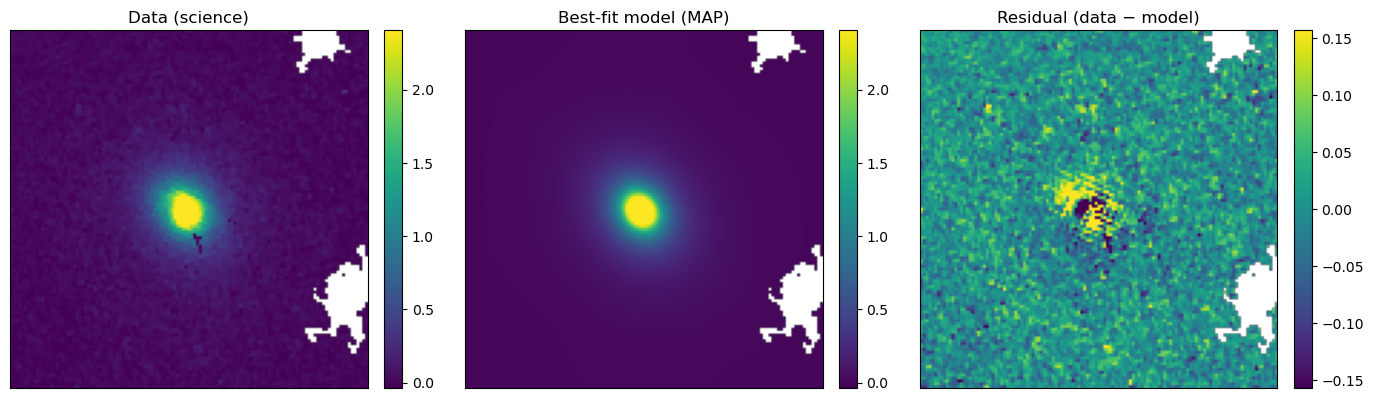

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import jax.random as jr

# --- random keys ---
rkey = jr.PRNGKey(0)
rkey_map, rkey_post = jr.split(rkey, 2)

# --- 1) MAP (return_model=True gives model image in dict) ---
map_res = fitter.find_MAP(rkey_map, return_model=True)
print("MAP keys:", list(map_res.keys()))

# Extract MAP params as a dict using the known parameter names
param_names = priors.param_names  # ['flux','xc','yc','r_eff','ellip','theta','n']
map_params = {p: float(np.array(map_res[p])) for p in param_names}

print("\nMAP parameter values:")
for p in param_names:
    print(f"  {p:6s} = {map_params[p]}")

# Extract model image
model = np.array(map_res["model"])
print("\nModel shape:", model.shape)

# --- 2) Posterior around MAP ---
results = fitter.estimate_posterior(rkey_post, method="laplace", return_model=True, num_sample=1000)
print("\nPosterior object:", type(results))

# --- 3) Plot data/model/residual (Output 3) ---
data = np.array(image)

data_plot  = np.where(mask_bool, np.nan, data)
model_plot = np.where(mask_bool, np.nan, model)
resid_plot = np.where(mask_bool, np.nan, data - model)

vmin = np.nanpercentile(data_plot, 5)
vmax = np.nanpercentile(data_plot, 99.5)
rv   = np.nanpercentile(np.abs(resid_plot), 99)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

im0 = ax[0].imshow(data_plot, origin="lower", vmin=vmin, vmax=vmax)
ax[0].set_title("Data (science)")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(model_plot, origin="lower", vmin=vmin, vmax=vmax)
ax[1].set_title("Best-fit model (MAP)")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(resid_plot, origin="lower", vmin=-rv, vmax=rv)
ax[2].set_title("Residual (data − model)")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()

# Save for Step 3.4
MAP_PARAMS = map_params
RESULTS = results

In [32]:
print("RESULTS attributes (filtered):")
print([a for a in dir(RESULTS) if ("quant" in a.lower() or "retriev" in a.lower() or "param" in a.lower() or "poster" in a.lower() or "sample" in a.lower())])

RESULTS attributes (filtered):
['retrieve_med_std', 'retrieve_param_quantiles', 'sample_posterior']


### Step 3.4 — one cell to report 16/50/84 percentiles for r_eff, n, flux

In [35]:
import inspect
print(inspect.signature(RESULTS.retrieve_param_quantiles))

(quantiles: Union[<built-in function array>, array, list] = [0.16, 0.5, 0.84], return_dataframe: bool = False) -> Union[pandas.DataFrame, dict]


In [ ]:
import numpy as np

qs = [0.16, 0.50, 0.84]

# returns a dict OR dataframe with entries for each parameter
qtab = RESULTS.retrieve_paramquantiles(quantiles=qs, return_dataframe=False)

print("Quantiles available for parameters:", list(qtab.keys()))

params = ["r_eff", "n", "flux"]

print("\nReported values (50th percentile with 16th/84th errors):")
for p in params:
    q16, q50, q84 = qtab[p]
    err_lo = q50 - q16
    err_hi = q84 - q50
    print(f"{p:5s} = {q50:.4g}  -{err_lo:.3g}  +{err_hi:.3g}")

Quantiles available for parameters: ['ellip', 'flux', 'n', 'r_eff', 'theta', 'xc', 'yc']

Reported values (50th percentile with 16th/84th errors):
r_eff = 11.37  -0.113  +0.11
n     = 2.47  -0.0339  +0.0317
flux  = 1476  -8.63  +8.24


In [37]:
# === Week 6 — Step 3 (batch mode): run 3.1–3.4 for all 6 galaxies and make a summary table ===
# This cell will:
#  - load each galaxy's sci/sigma/mask + the PSF
#  - build priors with autoprior(profile_type="sersic")
#  - run MAP (find_MAP) + posterior (estimate_posterior, Laplace)
#  - extract 16/50/84% quantiles for r_eff, n, flux
#  - save per-galaxy diagnostic plots (data/model/residual)
#  - return a pandas table with results for Sample1-1..3 and Sample2-1..3

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
import jax.random as jr

from pysersic import FitSingle
from pysersic.priors import autoprior

# ---------- user settings ----------
base_dir = "."  # folder containing Sample1/, Sample2/, and psf-f277w-clear.fits
psf_path = os.path.join(base_dir, "psf-f277w-clear.fits")

# posterior settings (Laplace is fast; num_sample controls posterior sample size)
posterior_method = "laplace"
num_sample = 1000

# where to save figures
out_dir = os.path.join(base_dir, "pysersic_outputs")
os.makedirs(out_dir, exist_ok=True)

# ---------- load and normalize PSF once ----------
with fits.open(psf_path) as hdul:
    psf = hdul[0].data.astype(float)
psf = np.nan_to_num(psf, nan=0.0)
psf_sum = psf.sum()
if psf_sum <= 0:
    raise ValueError("PSF sum is non-positive; cannot normalize.")
psf /= psf_sum
print("PSF loaded:", psf.shape, "sum=", psf.sum())

# ---------- helper: run one galaxy ----------
def run_one(sample, gal_id, rkey):
    sci_path   = os.path.join(base_dir, f"Sample{sample}", f"Sample{sample}-{gal_id}_f277w-clear_sci.fits")
    sigma_path = os.path.join(base_dir, f"Sample{sample}", f"Sample{sample}-{gal_id}_f277w-clear_sigma.fits")
    mask_path  = os.path.join(base_dir, f"Sample{sample}", f"Sample{sample}-{gal_id}_f277w-clear_mask.fits")

    image = fits.open(sci_path)[0].data.astype(float)
    sigma = fits.open(sigma_path)[0].data.astype(float)
    mask  = fits.open(mask_path)[0].data.astype(float)

    mask_bool = (mask > 0)

    # priors + fitter (match YOUR PySersic API)
    priors = autoprior(image, mask=mask_bool, profile_type="sersic")
    fitter = FitSingle(data=image, rms=sigma, psf=psf, prior=priors, mask=mask_bool)

    # split key for MAP and posterior
    rkey_map, rkey_post = jr.split(rkey, 2)

    # MAP (return_model=True gives model image in map_res["model"])
    map_res = fitter.find_MAP(rkey_map, return_model=True)
    model = np.array(map_res["model"])

    # posterior (returns PySersicResults in your version)
    results = fitter.estimate_posterior(rkey_post, method=posterior_method, return_model=True, num_sample=num_sample)

    # quantiles for all params -> select r_eff, n, flux
    qs = [0.16, 0.50, 0.84]
    qtab = results.retrieve_param_quantiles(quantiles=qs, return_dataframe=False)

    def pack_param(p):
        q16, q50, q84 = qtab[p]
        return float(q50), float(q50 - q16), float(q84 - q50)

    r_eff_50, r_eff_lo, r_eff_hi = pack_param("r_eff")
    n_50,     n_lo,     n_hi     = pack_param("n")
    flux_50,  flux_lo,  flux_hi  = pack_param("flux")

    # diagnostic plot (data/model/residual)
    data = np.array(image)
    data_plot  = np.where(mask_bool, np.nan, data)
    model_plot = np.where(mask_bool, np.nan, model)
    resid_plot = np.where(mask_bool, np.nan, data - model)

    vmin = np.nanpercentile(data_plot, 5)
    vmax = np.nanpercentile(data_plot, 99.5)
    rv   = np.nanpercentile(np.abs(resid_plot), 99)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    im0 = ax[0].imshow(data_plot, origin="lower", vmin=vmin, vmax=vmax)
    ax[0].set_title(f"Data S{sample}-{gal_id}")
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

    im1 = ax[1].imshow(model_plot, origin="lower", vmin=vmin, vmax=vmax)
    ax[1].set_title("MAP model")
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

    im2 = ax[2].imshow(resid_plot, origin="lower", vmin=-rv, vmax=rv)
    ax[2].set_title("Residual (data-model)")
    plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

    for a in ax:
        a.set_xticks([]); a.set_yticks([])

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f"S{sample}-{gal_id}_output3_residual.png")
    plt.savefig(fig_path, dpi=180)
    plt.close(fig)

    return {
        "sample": sample,
        "gal_id": gal_id,
        "sci_path": sci_path,
        "masked_frac": float(mask_bool.mean()),
        "r_eff_p50_pix": r_eff_50,
        "r_eff_err_lo_pix": r_eff_lo,
        "r_eff_err_hi_pix": r_eff_hi,
        "n_p50": n_50,
        "n_err_lo": n_lo,
        "n_err_hi": n_hi,
        "flux_p50": flux_50,
        "flux_err_lo": flux_lo,
        "flux_err_hi": flux_hi,
        "output3_fig": fig_path,
    }

# ---------- run all 6 ----------
rows = []
master_key = jr.PRNGKey(42)  # reproducible
keys = jr.split(master_key, 6)

k = 0
for sample in [1, 2]:
    for gal_id in [1, 2, 3]:
        print(f"\n=== Running Sample{sample}-{gal_id} ===")
        rows.append(run_one(sample, gal_id, keys[k]))
        k += 1

df = pd.DataFrame(rows).sort_values(["sample", "gal_id"]).reset_index(drop=True)

# nicer summary columns (what you report in Step 3.4)
summary = df[[
    "sample","gal_id",
    "r_eff_p50_pix","r_eff_err_lo_pix","r_eff_err_hi_pix",
    "n_p50","n_err_lo","n_err_hi",
    "flux_p50","flux_err_lo","flux_err_hi",
    "output3_fig"
]]

display(summary)
print("\nSaved Output 3 diagnostic figures to:", out_dir)

PSF loaded: (121, 121) sum= 1.0

=== Running Sample1-1 ===


/Users/alberto/miniforge3/envs/masssize/lib/python3.11/site-packages/pysersic/pysersic.py:75: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.renderer = renderer(data.shape, self.psf, **renderer_kwargs)
  1%|▏         | 253/20000 [00:00<00:13, 1517.73it/s, Round = 2,step_size = 5.0e-04 loss: -2.418e+04]



=== Running Sample1-2 ===


/Users/alberto/miniforge3/envs/masssize/lib/python3.11/site-packages/pysersic/pysersic.py:75: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.renderer = renderer(data.shape, self.psf, **renderer_kwargs)
  1%|▏         | 252/20000 [00:00<00:15, 1271.89it/s, Round = 2,step_size = 5.0e-04 loss: -2.432e+04]



=== Running Sample1-3 ===


...

/Users/alberto/miniforge3/envs/masssize/lib/python3.11/site-packages/pysersic/pysersic.py:75: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.renderer = renderer(data.shape, self.psf, **renderer_kwargs)
  1%|▏         | 256/20000 [00:00<00:13, 1492.27it/s, Round = 2,step_size = 5.0e-04 loss: -2.887e+04]



=== Running Sample2-3 ===


/Users/alberto/miniforge3/envs/masssize/lib/python3.11/site-packages/pysersic/pysersic.py:75: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.renderer = renderer(data.shape, self.psf, **renderer_kwargs)
  1%|▏         | 251/20000 [00:00<00:13, 1506.49it/s, Round = 2,step_size = 5.0e-04 loss: -2.472e+04]


,sample,gal_id,r_eff_p50_pix,r_eff_err_lo_pix,r_eff_err_hi_pix,n_p50,n_err_lo,n_err_hi,flux_p50,flux_err_lo,flux_err_hi,output3_fig
0,1,1,3.334257,0.044852,0.046096,3.821635,0.110486,0.107386,702.582581,4.974773,4.749434,./pysersic_outputs/S1-1_output3_residual.png
1,1,2,11.368941,0.112779,0.109626,2.470328,0.033906,0.031662,1476.171631,8.634399,8.243237,./pysersic_outputs/S1-2_output3_residual.png
2,1,3,4.429357,0.010445,0.011068,2.433885,0.012351,0.012413,1755.700317,2.277393,2.174292,./pysersic_outputs/S1-3_output3_residual.png
3,2,1,13.936387,0.089491,0.084783,2.022979,0.020170,0.022679,1767.947205,7.897288,7.539578,./pysersic_outputs/S2-1_output3_residual.png
4,2,2,6.834592,0.051639,0.052569,1.835732,0.028608,0.027368,609.968475,3.027362,2.890260,./pysersic_outputs/S2-2_output3_residual.png
5,2,3,8.530054,0.038238,0.040842,0.650992,0.000605,0.001420,399.829956,1.739238,1.660463,./pysersic_outputs/S2-3_output3_residual.png



Saved Output 3 diagnostic figures to: ./pysersic_outputs


In [38]:
hdr = fits.open("./Sample1/Sample1-1_f277w-clear_sci.fits")[0].header
print(hdr["CDELT1"], hdr.get("PIXELSCL", "no PIXELSCL key"))

1.0 no PIXELSCL key


In [39]:
pixscale = 0.04  # arcsec/pixel (given in the exercise notes)

df["r_eff_p50_arcsec"] = df["r_eff_p50_pix"] * pixscale
df["r_eff_err_lo_arcsec"] = df["r_eff_err_lo_pix"] * pixscale
df["r_eff_err_hi_arcsec"] = df["r_eff_err_hi_pix"] * pixscale

display(df[["sample","gal_id",
            "r_eff_p50_pix","r_eff_err_lo_pix","r_eff_err_hi_pix",
            "r_eff_p50_arcsec","r_eff_err_lo_arcsec","r_eff_err_hi_arcsec",
            "n_p50","flux_p50"]])

,sample,gal_id,r_eff_p50_pix,r_eff_err_lo_pix,r_eff_err_hi_pix,r_eff_p50_arcsec,r_eff_err_lo_arcsec,r_eff_err_hi_arcsec,n_p50,flux_p50
0,1,1,3.334257,0.044852,0.046096,0.133370,0.001794,0.001844,3.821635,702.582581
1,1,2,11.368941,0.112779,0.109626,0.454758,0.004511,0.004385,2.470328,1476.171631
2,1,3,4.429357,0.010445,0.011068,0.177174,0.000418,0.000443,2.433885,1755.700317
3,2,1,13.936387,0.089491,0.084783,0.557455,0.003580,0.003391,2.022979,1767.947205
4,2,2,6.834592,0.051639,0.052569,0.273384,0.002066,0.002103,1.835732,609.968475
5,2,3,8.530054,0.038238,0.040842,0.341202,0.001530,0.001634,0.650992,399.829956


### Step 4 — one cell (arcsec → kpc at z=2.3) [Output 4]

In [40]:
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

z = 2.3

# Astropy gives transverse proper kpc per arcmin at redshift z
kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(z)  # quantity with units kpc/arcmin
kpc_per_arcsec = (kpc_per_arcmin / (60.0 * u.arcsec)) * u.arcsec  # -> kpc/arcsec

print(f"At z={z}: {kpc_per_arcmin:.3f} per arcmin")
print(f"At z={z}: {kpc_per_arcsec:.3f} per arcsec")

# Convert median and errors (propagate linearly since it's a scale factor)
df["r_eff_p50_kpc"] = df["r_eff_p50_arcsec"] * kpc_per_arcsec.value
df["r_eff_err_lo_kpc"] = df["r_eff_err_lo_arcsec"] * kpc_per_arcsec.value
df["r_eff_err_hi_kpc"] = df["r_eff_err_hi_arcsec"] * kpc_per_arcsec.value

# Output 4: show table
out4 = df[[
    "sample","gal_id",
    "r_eff_p50_arcsec","r_eff_err_lo_arcsec","r_eff_err_hi_arcsec",
    "r_eff_p50_kpc","r_eff_err_lo_kpc","r_eff_err_hi_kpc",
    "n_p50","flux_p50"
]].copy()

display(out4)

At z=2.3: 504.248 kpc / arcmin per arcmin
At z=2.3: 8.404 kpc / arcmin per arcsec


,sample,gal_id,r_eff_p50_arcsec,r_eff_err_lo_arcsec,r_eff_err_hi_arcsec,r_eff_p50_kpc,r_eff_err_lo_kpc,r_eff_err_hi_kpc,n_p50,flux_p50
0,1,1,0.133370,0.001794,0.001844,1.120861,0.015078,0.015496,3.821635,702.582581
1,1,2,0.454758,0.004511,0.004385,3.821840,0.037912,0.036852,2.470328,1476.171631
2,1,3,0.177174,0.000418,0.000443,1.488995,0.003511,0.003721,2.433885,1755.700317
3,2,1,0.557455,0.003580,0.003391,4.684926,0.030084,0.028501,2.022979,1767.947205
4,2,2,0.273384,0.002066,0.002103,2.297551,0.017359,0.017672,1.835732,609.968475
5,2,3,0.341202,0.001530,0.001634,2.867506,0.012854,0.013730,0.650992,399.829956


### Step 5 — Flux → M\* at z=2.3 (Output 5)

In [41]:
hdr = fits.open("./Sample1/Sample1-1_f277w-clear_sci.fits")[0].header
for key in hdr.keys():
    if "ZP" in key or "MAG" in key or "PHOT" in key:
        print(key, "=", hdr[key])

PHOTMJSR = 0.4907999932765961
PHOTSCAL = 0.9417969485778865
OPHOTFNU = 9.30775449348276e-08
PHOTFNU = 1e-08


In [42]:
import numpy as np
from astropy.io import fits
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

# -----------------------
# Settings from exercise
# -----------------------
z = 2.3
pixscale_arcsec = 0.04                       # arcsec/pix (given)
m_sun_K = 5.17                               # mag (given)
log10_ML = -0.27*z - 0.28                    # eq. (3)
print(f"log10(M*/L_K) at z={z} = {log10_ML:.4f}")

# -----------------------
# Pixel solid angle
# -----------------------
pix_area_sr = (pixscale_arcsec * u.arcsec).to(u.rad).value**2  # sr per pixel
# (small-angle: (theta_rad)^2)
print(f"Pixel area = {pix_area_sr:.3e} sr")

# -----------------------
# Determine image units and conversion from header
# -----------------------
hdr = fits.open("./Sample1/Sample1-1_f277w-clear_sci.fits")[0].header
bunit = (hdr.get("BUNIT", "") or "").strip()
photmjsr = hdr.get("PHOTMJSR", None)

print("BUNIT =", repr(bunit))
print("PHOTMJSR =", photmjsr)

def fluxsum_to_Jy(fluxsum, bunit, photmjsr, pix_area_sr):
    """
    Convert summed pixel values (fluxsum) into integrated flux density in Jy.
    Handles common JWST cases:
      - If BUNIT contains 'MJy/sr': fluxsum is sum of MJy/sr values over pixels.
      - If not MJy/sr and PHOTMJSR exists: assume data is in DN/s and multiply by PHOTMJSR -> MJy/sr.
    """
    # Convert to MJy/sr map-sum first
    if "MJy" in bunit and "/sr" in bunit:
        fluxsum_mjy_sr = fluxsum
        conv_note = "Used science image as MJy/sr (no PHOTMJSR applied)."
    else:
        if photmjsr is None:
            raise ValueError("BUNIT is not MJy/sr and PHOTMJSR is missing; cannot calibrate flux to Jy.")
        fluxsum_mjy_sr = fluxsum * float(photmjsr)
        conv_note = "Converted DN/s -> MJy/sr using PHOTMJSR."

    # Integrated flux density: (MJy/sr) * (sr) = MJy ; then MJy -> Jy (1 MJy = 1e6 Jy)
    f_jy = fluxsum_mjy_sr * pix_area_sr * 1e6
    return f_jy, conv_note

# Conversion note
_, note = fluxsum_to_Jy(df.loc[0, "flux_p50"], bunit, photmjsr, pix_area_sr)
print("Flux calibration:", note)

# -----------------------
# Helper: Jy -> AB magnitude
# -----------------------
def jy_to_mab(f_jy):
    return -2.5*np.log10(f_jy/3631.0)

# -----------------------
# Distances at z
# -----------------------
DL_pc = cosmo.luminosity_distance(z).to(u.pc).value
DM = 5*(np.log10(DL_pc) - 1)  # distance modulus
print(f"DL(z={z}) = {DL_pc:.3e} pc,  distance modulus DM = {DM:.4f} mag")

# -----------------------
# Compute M* using flux 16/50/84 to propagate uncertainties
# -----------------------
# Build flux quantiles from your table (asymmetric errors)
df["flux_q16"] = df["flux_p50"] - df["flux_err_lo"]
df["flux_q50"] = df["flux_p50"]
df["flux_q84"] = df["flux_p50"] + df["flux_err_hi"]

def fluxsum_to_logM(fluxsum):
    f_jy, _ = fluxsum_to_Jy(fluxsum, bunit, photmjsr, pix_area_sr)
    m_obs = jy_to_mab(f_jy)
    m_abs = m_obs - DM                           # eq. (4) as given (no k-corr)
    Lk = 10**(-0.4*(m_abs - m_sun_K))             # eq. (5) in Lsun
    logM = np.log10(Lk) + log10_ML                # log10(M*) in Msun
    return logM, m_obs, m_abs, Lk, f_jy

# compute for each galaxy using q16/q50/q84
logM16, logM50, logM84 = [], [], []
mobs50_list, mabs50_list, Lk50_list, fJy50_list = [], [], [], []

for _, row in df.iterrows():
    lm16, *_ = fluxsum_to_logM(row["flux_q16"])
    lm50, m_obs, m_abs, Lk, f_jy = fluxsum_to_logM(row["flux_q50"])
    lm84, *_ = fluxsum_to_logM(row["flux_q84"])

    logM16.append(lm16); logM50.append(lm50); logM84.append(lm84)
    mobs50_list.append(m_obs); mabs50_list.append(m_abs); Lk50_list.append(Lk); fJy50_list.append(f_jy)

df["m_obs_AB"] = mobs50_list
df["m_abs"] = mabs50_list
df["Lk_Lsun"] = Lk50_list
df["flux_Jy"] = fJy50_list

df["logMstar_p50"] = logM50
df["logMstar_err_lo"] = np.array(logM50) - np.array(logM16)
df["logMstar_err_hi"] = np.array(logM84) - np.array(logM50)

# Output 5 table
out5 = df[[
    "sample","gal_id",
    "flux_p50","flux_err_lo","flux_err_hi",
    "flux_Jy","m_obs_AB","m_abs","Lk_Lsun",
    "logMstar_p50","logMstar_err_lo","logMstar_err_hi",
    "r_eff_p50_kpc"
]].copy()

display(out5)

log10(M*/L_K) at z=2.3 = -0.9010
Pixel area = 3.761e-14 sr
BUNIT = ''
PHOTMJSR = 0.4907999932765961
Flux calibration: Converted DN/s -> MJy/sr using PHOTMJSR.
DL(z=2.3) = 1.888e+10 pc,  distance modulus DM = 46.3797 mag


,sample,gal_id,flux_p50,flux_err_lo,flux_err_hi,flux_Jy,m_obs_AB,m_abs,Lk_Lsun,logMstar_p50,logMstar_err_lo,logMstar_err_hi,r_eff_p50_kpc
0,1,1,702.582581,4.974773,4.749434,0.000013,21.117887,-25.261841,1.488458e+12,11.271736,0.003086,0.002926,1.120861
1,1,2,1476.171631,8.634399,8.243237,0.000027,20.311788,-26.067940,3.127346e+12,11.594176,0.002548,0.002418,3.821840
2,1,3,1755.700317,2.277393,2.174292,0.000032,20.123504,-26.256224,3.719542e+12,11.669490,0.000564,0.000538,1.488995
3,2,1,1767.947205,7.897288,7.539578,0.000033,20.115957,-26.263771,3.745488e+12,11.672508,0.001944,0.001848,4.684926
4,2,2,609.968475,3.027362,2.890260,0.000011,21.271361,-25.108366,1.292250e+12,11.210347,0.002161,0.002053,2.297551
5,2,3,399.829956,1.739238,1.660463,0.000007,21.729942,-24.649786,8.470605e+11,11.026914,0.001893,0.001800,2.867506


### Step 6 — one cell (Output 6): plot + overplot early/late relations (2<z<2.5)

In [43]:
df["Mstar_p50"] = 10**df["logMstar_p50"]
display(df[["sample","gal_id","r_eff_p50_kpc","n_p50","logMstar_p50"]])

,sample,gal_id,r_eff_p50_kpc,n_p50,logMstar_p50
0,1,1,1.120861,3.821635,11.271736
1,1,2,3.821840,2.470328,11.594176
2,1,3,1.488995,2.433885,11.669490
3,2,1,4.684926,2.022979,11.672508
4,2,2,2.297551,1.835732,11.210347
5,2,3,2.867506,0.650992,11.026914


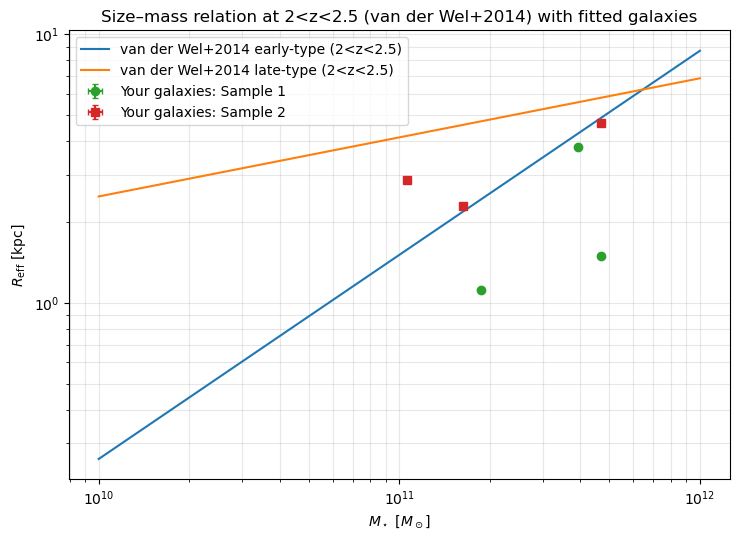

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --- van der Wel+2014 (Table 1), redshift bin z=2.25 (represents 2<z<2.5) ---
# Reff/kpc = A * (M*/(5e10 Msun))^alpha
logA_early, alpha_early = -0.05, 0.76
logA_late,  alpha_late  =  0.55, 0.22

A_early = 10**logA_early
A_late  = 10**logA_late

def Re_vdw(M, A, alpha):
    return A * (M/(5e10))**alpha

# Mass grid for the relation curves (Msun)
M_grid = np.logspace(10.0, 12.0, 300)

Re_early = Re_vdw(M_grid, A_early, alpha_early)
Re_late  = Re_vdw(M_grid, A_late,  alpha_late)

# --- Your galaxy points ---
M_star = 10**df["logMstar_p50"].values
Re_kpc = df["r_eff_p50_kpc"].values

# Optional: include size errors (from Step 4)
Re_lo = df["r_eff_err_lo_kpc"].values
Re_hi = df["r_eff_err_hi_kpc"].values

# Optional: include mass errors (from Step 5) in log space -> convert to linear
logM_lo = df["logMstar_err_lo"].values
logM_hi = df["logMstar_err_hi"].values
M_lo = M_star - 10**(df["logMstar_p50"].values - logM_lo)
M_hi = 10**(df["logMstar_p50"].values + logM_hi) - M_star

# --- Plot ---
plt.figure(figsize=(7.5, 5.5))

# Relations
plt.plot(M_grid, Re_early, label="van der Wel+2014 early-type (2<z<2.5)")
plt.plot(M_grid, Re_late,  label="van der Wel+2014 late-type (2<z<2.5)")

# Points: different marker by sample (no manual colors)
for sample, marker in [(1, "o"), (2, "s")]:
    sel = (df["sample"].values == sample)
    plt.errorbar(
        M_star[sel], Re_kpc[sel],
        xerr=[M_lo[sel], M_hi[sel]],
        yerr=[Re_lo[sel], Re_hi[sel]],
        fmt=marker, capsize=2, linestyle="None",
        label=f"Your galaxies: Sample {sample}"
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$M_\star\ [M_\odot]$")
plt.ylabel(r"$R_{\rm eff}\ [{\rm kpc}]$")
plt.title("Size–mass relation at 2<z<2.5 (van der Wel+2014) with fitted galaxies")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Step 7 — Shape differences between Sample 1 and Sample 2

In [45]:
import numpy as np

def summarize(group):
    return {
        "Re_kpc_median": np.median(group["r_eff_p50_kpc"]),
        "Re_kpc_mean": np.mean(group["r_eff_p50_kpc"]),
        "n_median": np.median(group["n_p50"]),
        "n_mean": np.mean(group["n_p50"]),
    }

print("Sample 1 summary:", summarize(df[df["sample"]==1]))
print("Sample 2 summary:", summarize(df[df["sample"]==2]))

Sample 1 summary: {'Re_kpc_median': np.float64(1.4889949241531089), 'Re_kpc_mean': np.float64(2.143898597615361), 'n_median': np.float64(2.470328211784363), 'n_mean': np.float64(2.9086161057154336)}
Sample 2 summary: {'Re_kpc_median': np.float64(2.8675058473876582), 'Re_kpc_mean': np.float64(3.2833274727033235), 'n_median': np.float64(1.8357322812080383), 'n_mean': np.float64(1.5032344957192738)}


### Step 8 — Which sample is more likely early-type?

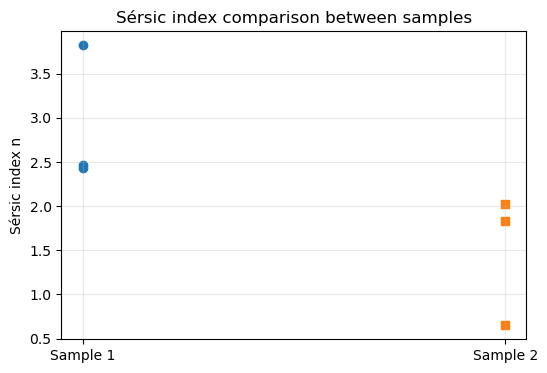

Median n:
Sample 1: 2.470328211784363
Sample 2: 1.8357322812080383

Median Re (kpc):
Sample 1: 1.4889949241531089
Sample 2: 2.8675058473876582


In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for sample, marker in [(1, "o"), (2, "s")]:
    sel = (df["sample"] == sample)
    plt.scatter(
        [sample]*np.sum(sel),
        df.loc[sel, "n_p50"],
        marker=marker
    )

plt.xticks([1,2], ["Sample 1","Sample 2"])
plt.ylabel("Sérsic index n")
plt.title("Sérsic index comparison between samples")
plt.grid(alpha=0.3)
plt.show()

print("Median n:")
print("Sample 1:", np.median(df[df["sample"]==1]["n_p50"]))
print("Sample 2:", np.median(df[df["sample"]==2]["n_p50"]))

print("\nMedian Re (kpc):")
print("Sample 1:", np.median(df[df["sample"]==1]["r_eff_p50_kpc"]))
print("Sample 2:", np.median(df[df["sample"]==2]["r_eff_p50_kpc"]))